In [8]:
%pip install --user --upgrade numpy scipy

     |████████████████████████████████| 19.5 MB 11.4 MB/s            
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from scipy.stats import f_oneway
from matplotlib import pyplot as plt


files = {
    #"large1": "/home/mengelsl/MA-bench-framework/benchmark/spmv_deep_analysis/large1.csv",
    #"large2": "/home/mengelsl/MA-bench-framework/benchmark/spmv_deep_analysis/large2.csv",
    #"large3": "/home/mengelsl/MA-bench-framework/benchmark/spmv_deep_analysis/large3.csv",
    #"large4": "/home/mengelsl/MA-bench-framework/benchmark/spmv_deep_analysis/large4.csv",
    #"large5": "/home/mengelsl/MA-bench-framework/benchmark/spmv_deep_analysis/large5.csv",
    "huge1": "/home/mengelsl/MA-bench-framework/benchmark/spmv_deep_analysis/huge1.csv",
    "huge2": "/home/mengelsl/MA-bench-framework/benchmark/spmv_deep_analysis/huge2.csv",

}
#CSV format:
#Matrix,Cores,Run,Type,Iteration,Runtime,Gflops
all_data = []
for name, path in files.items():
    df = pd.read_csv(path,index_col=False)
    df['Environment'] = name 
    all_data.append(df)

df = pd.concat(all_data, ignore_index=True)
df_iter=df[(df['Type'] == 'ITER') & (df['Cores'] == 72)]
df_io=df[df['Type'] == 'IO_LOAD']

In [19]:
df_iter.groupby('Environment')['Gflops'].agg(['mean', 'std'])

,mean,std
Environment,,
large1,17.419417,0.297908
large2,17.328620,0.339546
large3,17.286286,0.336108
large4,17.493572,0.320446
large5,17.444377,0.358290


Number of runs per environment: {'huge1': 30, 'huge2': 30}


/tmp/ipykernel_2369532/3973948521.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Environment', y='mean_Gflops', data=run_means, palette="Set3")


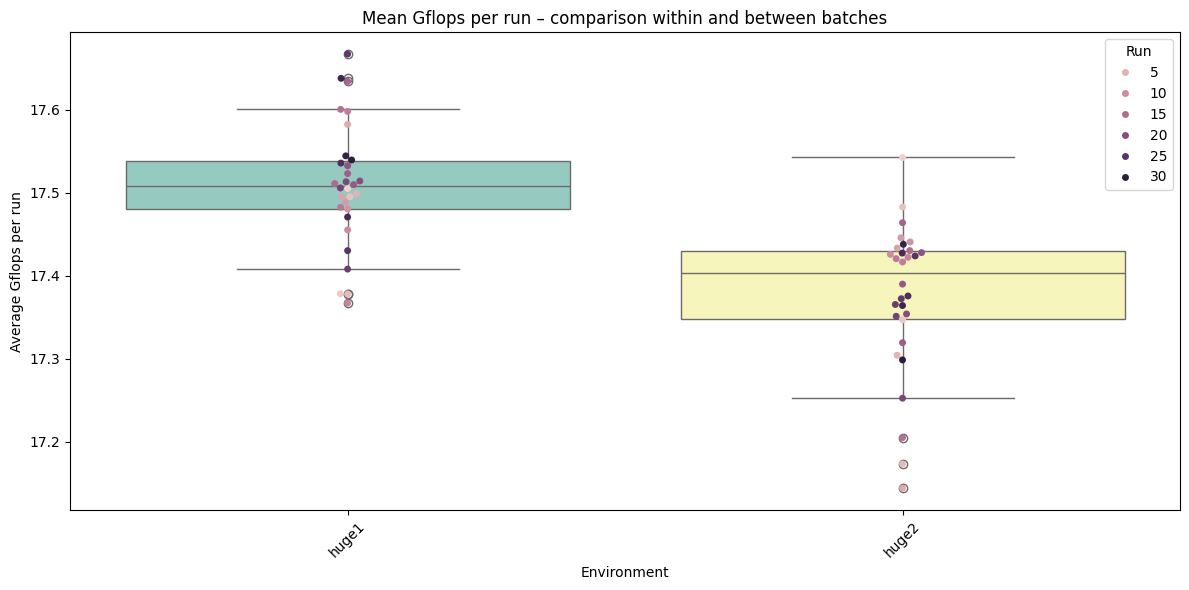


=== VARIANCES ===
Average variance WITHIN a file (run-to-run): 0.0069
Variance BETWEEN files (host means):         0.0090
Ratio (between / within):                    1.31

=== ANOVA RESULTS ===
F-statistic:      39.3298
p-value:          0.000000
→ SIGNIFICANT difference between hosts (p < 0.05)!
   The runs within a file are strongly correlated.
   You should consider the environment (host) as a factor.

Intra-Class Correlation (ICC): 0.1844  (the higher, the stronger runs within a file are correlated)


In [50]:
run_means = (
    df_iter
    .groupby(['Environment', 'Run'])['Gflops']
    .mean()
    .reset_index(name='mean_Gflops')
)

print("Number of runs per environment:", run_means.groupby('Environment')['Run'].count().to_dict())

plt.figure(figsize=(12, 6))
sns.boxplot(x='Environment', y='mean_Gflops', data=run_means, palette="Set3")
sns.swarmplot(x='Environment', y='mean_Gflops', data=run_means,hue='Run')
plt.title('Mean Gflops per run – comparison within and between batches')
plt.xlabel('Environment')
plt.ylabel('Average Gflops per run')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

groups = []
env_means = []
within_vars = []

for env, group in run_means.groupby('Environment'):
    run_values = group['mean_Gflops'].values
    groups.append(run_values)
    env_means.append(np.mean(run_values))
    within_vars.append(np.var(run_values, ddof=1)) 

avg_within_variance = np.mean(within_vars)         
between_variance = np.var(env_means, ddof=1)        

print("\n=== VARIANCES ===")
print(f"Average variance WITHIN a file (run-to-run): {avg_within_variance:.4f}")
print(f"Variance BETWEEN files (host means):         {between_variance:.4f}")
print(f"Ratio (between / within):                    {between_variance / avg_within_variance:.2f}")

f_stat, p_value = f_oneway(*groups)

print("\n=== ANOVA RESULTS ===")
print(f"F-statistic:      {f_stat:.4f}")
print(f"p-value:          {p_value:.6f}")

if p_value < 0.05:
    print("→ SIGNIFICANT difference between hosts (p < 0.05)!")
    print("   The runs within a file are strongly correlated.")
    print("   You should consider the environment (host) as a factor.")
else:
    print("→ NO significant difference between hosts (p >= 0.05).")
    print("   Runs can be considered individually – independent of the file.")

grand_mean = np.mean(env_means)
ss_between = 10 * np.sum((np.array(env_means) - grand_mean)**2)  #Runs per host
ss_within = sum(np.sum((g - np.mean(g))**2) for g in groups)
icc = ss_between / (ss_between + ss_within)
print(f"\nIntra-Class Correlation (ICC): {icc:.4f}  (the higher, the stronger runs within a file are correlated)")

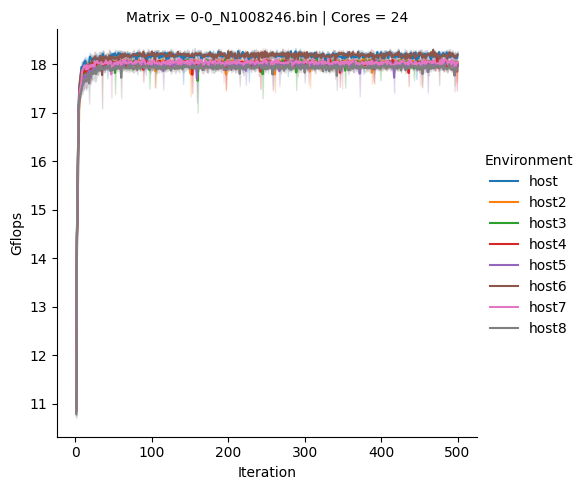

In [15]:
g = sns.relplot(
    data=df_iter, 
    x='Iteration', 
    y='Gflops', 
    hue='Environment',     
    col='Cores',      
	row='Matrix',       
    kind='line', 
    facet_kws={'sharey': False}, 
)

in jedem host run -> 5 runs , darin pro iter den std nehmen

In [25]:
for file in files.keys():
	df_single = df_iter[df_iter['Environment'] == file]
	df_std = df_single.groupby(['Matrix', 'Cores','Iteration'])['Gflops'].std().reset_index(name='Gflops_std')
	mean = df_std["Gflops_std"].mean()
	print(f"{file}: {mean}")


host1: 0.08363225254627313
host2: 0.08001127720328481
host3: 0.08064715701800575
host4: 0.0785511465783191
host5: 0.0790866060978347
host6: 0.08532432040077996
host7: 0.08065619325027629
host8: 0.07701019726611377
